In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('IPL stats 2008-27.csv')

df = df.drop(columns=['Unnamed: 0'])

df['date'] = pd.to_datetime(df['date'])

In [4]:
batter_summary = (
    df.groupby('batter')
    .agg(
        Runs=('runs_batter','sum'),
        Balls=('balls_faced','sum')
    )
    .reset_index()
)

In [6]:
batter_summary['StrikeRate']=(
    batter_summary['Runs']
    / batter_summary['Balls']
)*100

In [7]:
batter_summary.head()

,batter,Runs,Balls,StrikeRate
0,A Ashish Reddy,280,193,145.077720
1,A Badoni,963,695,138.561151
2,A Chandila,4,7,57.142857
3,A Chopra,53,71,74.647887
4,A Choudhary,25,20,125.000000


In [8]:
batter_summary.describe()

,Runs,Balls,StrikeRate
count,703.000000,703.000000,703.000000
mean,505.509246,382.823613,106.721050
std,1071.494044,792.085539,43.216152
min,0.000000,1.000000,0.000000
25%,15.000000,16.500000,81.250000
50%,75.000000,73.000000,112.500000
75%,386.500000,299.500000,133.784438
max,8671.000000,6523.000000,400.000000


In [9]:
qualified_batters = batter_summary[
    batter_summary['Balls']>=500
]

In [10]:
qualified_batters.sort_values(
    "Runs",
    ascending=False
).head(10)

,batter,Runs,Balls,StrikeRate
658,V Kohli,8671,6523,132.929634
500,RG Sharma,7048,5337,132.059209
535,S Dhawan,6769,5326,127.093504
151,DA Warner,6567,4702,139.663973
569,SK Raina,5536,4046,136.826495
389,MS Dhoni,5439,3957,137.452616
297,KL Rahul,5235,3848,136.044699
31,AB de Villiers,5181,3411,151.890941
51,AM Rahane,5032,4025,125.018634
128,CH Gayle,4997,3346,149.342499


In [11]:
qualified_batters.sort_values(
    "StrikeRate",
    ascending=False
).head(10)

,batter,Runs,Balls,StrikeRate
449,PD Salt,1056,601,175.707155
40,AD Russell,2655,1525,174.098361
643,TM Head,1146,674,170.029674
213,H Klaasen,1480,872,169.724771
412,N Pooran,2293,1359,168.727005
585,SP Narine,1780,1069,166.510758
71,Abhishek Sharma,1816,1114,163.016158
334,LS Livingstone,1051,662,158.761329
265,JM Sharma,991,631,157.052298
661,V Sehwag,2728,1755,155.441595


In [14]:
boundary_df = df[
    df["runs_batter"].isin([4,6])
]

In [15]:
boundary_summary = (
    boundary_df.groupby("batter")
    .agg(
        BoundaryRuns = ("runs_batter","sum")
    )
    .reset_index()
)


In [16]:
batter_summary = batter_summary.merge(
    boundary_summary,
    on="batter",
    how="left"
)

In [17]:
batter_summary['BoundaryRuns']=(
    batter_summary["BoundaryRuns"].fillna(0)
)

In [18]:
batter_summary["BoundaryPct"] = (
    batter_summary["BoundaryRuns"]
    /
    batter_summary["Runs"]
) * 100

In [19]:
top10 = (
    qualified_batters
    .sort_values("Runs",ascending=False)
    .head(10)
)

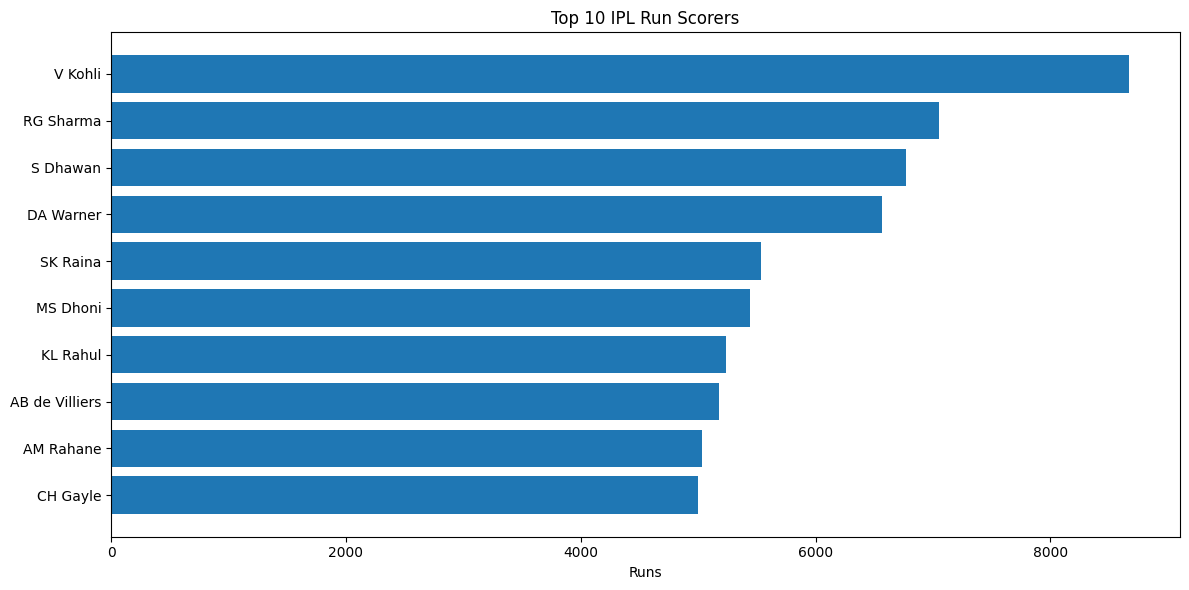

In [22]:
top10 = (
    qualified_batters
    .sort_values("Runs", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["batter"][::-1],
    top10["Runs"][::-1]
)

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Runs")
plt.tight_layout()
plt.show()

In [23]:
qualified_batters.sort_values(
    "StrikeRate",
    ascending=False
)[["batter","Runs","Balls","StrikeRate"]].head(15)

,batter,Runs,Balls,StrikeRate
449,PD Salt,1056,601,175.707155
40,AD Russell,2655,1525,174.098361
643,TM Head,1146,674,170.029674
213,H Klaasen,1480,872,169.724771
412,N Pooran,2293,1359,168.727005
585,SP Narine,1780,1069,166.510758
71,Abhishek Sharma,1816,1114,163.016158
334,LS Livingstone,1051,662,158.761329
265,JM Sharma,991,631,157.052298
661,V Sehwag,2728,1755,155.441595


In [24]:
 batter_summary.head()

,batter,Runs,Balls,StrikeRate,BoundaryRuns,BoundaryPct
0,A Ashish Reddy,280,193,145.077720,154.0,55.000000
1,A Badoni,963,695,138.561151,520.0,53.997923
2,A Chandila,4,7,57.142857,0.0,0.000000
3,A Chopra,53,71,74.647887,28.0,52.830189
4,A Choudhary,25,20,125.000000,10.0,40.000000


In [25]:
qualified_batters = batter_summary[
    batter_summary["Balls"] >= 500
]
qualified_batters.sort_values(
    "BoundaryPct",
    ascending=False
)[["batter","Runs","BoundaryRuns","BoundaryPct"]].head(15)

,batter,Runs,BoundaryRuns,BoundaryPct
585,SP Narine,1780,1452.0,81.573034
40,AD Russell,2655,2086.0,78.568738
449,PD Salt,1056,824.0,78.030303
128,CH Gayle,4997,3786.0,75.765459
594,ST Jayasuriya,768,570.0,74.218750
692,YBK Jaiswal,2166,1588.0,73.314866
443,P Simran Singh,1355,990.0,73.062731
33,AC Gilchrist,2069,1508.0,72.885452
643,TM Head,1146,834.0,72.774869
661,V Sehwag,2728,1972.0,72.287390


In [26]:
runs_min = batter_summary["Runs"].min()
runs_max = batter_summary["Runs"].max()

sr_min = batter_summary["StrikeRate"].min()
sr_max = batter_summary["StrikeRate"].max()

bp_min = batter_summary["BoundaryPct"].min()
bp_max = batter_summary["BoundaryPct"].max()

In [27]:
batter_summary["Runs_Scaled"] = (
    batter_summary["Runs"] - runs_min
) / (runs_max - runs_min)

batter_summary["SR_Scaled"] = (
    batter_summary["StrikeRate"] - sr_min
) / (sr_max - sr_min)

batter_summary["Boundary_Scaled"] = (
    batter_summary["BoundaryPct"] - bp_min
) / (bp_max - bp_min)

In [28]:
batter_summary["ImpactScore"] = (
    0.5 * batter_summary["Runs_Scaled"]
    +
    0.3 * batter_summary["SR_Scaled"]
    +
    0.2 * batter_summary["Boundary_Scaled"]
)

In [29]:
impact_players = batter_summary[
    batter_summary["Balls"] >= 500
]

In [30]:
impact_players.sort_values(
    "ImpactScore",
    ascending=False
)[[
    "batter",
    "Runs",
    "StrikeRate",
    "BoundaryPct",
    "ImpactScore"
]].head(20)

,batter,Runs,StrikeRate,BoundaryPct,ImpactScore
658,V Kohli,8671,132.929634,55.910506,0.711518
500,RG Sharma,7048,132.059209,62.116913,0.629690
151,DA Warner,6567,139.663973,61.946094,0.607316
535,S Dhawan,6769,127.093504,58.945191,0.603535
128,CH Gayle,4997,149.342499,75.765459,0.551682
569,SK Raina,5536,136.826495,58.670520,0.539186
31,AB de Villiers,5181,151.890941,61.262305,0.535197
389,MS Dhoni,5439,137.452616,56.701600,0.530124
297,KL Rahul,5235,136.044699,58.452722,0.520807
524,RV Uthappa,4954,130.334123,60.880097,0.505176


In [31]:
batter_summary["AggressiveImpact"] = (
    0.3*batter_summary["Runs_Scaled"]
    +
    0.5*batter_summary["SR_Scaled"]
    +
    0.2*batter_summary["Boundary_Scaled"]
)

In [32]:
impact_players = batter_summary[
    batter_summary["Balls"] >= 500
]

impact_players.sort_values(
    "AggressiveImpact",
    ascending=False
)[[
    "batter",
    "Runs",
    "StrikeRate",
    "BoundaryPct",
    "AggressiveImpact"
]].head(20)

,batter,Runs,StrikeRate,BoundaryPct,AggressiveImpact
658,V Kohli,8671,132.929634,55.910506,0.577983
500,RG Sharma,7048,132.059209,62.116913,0.533155
151,DA Warner,6567,139.663973,61.946094,0.525678
128,CH Gayle,4997,149.342499,75.765459,0.511096
535,S Dhawan,6769,127.093504,58.945191,0.510952
31,AB de Villiers,5181,151.890941,61.262305,0.491641
569,SK Raina,5536,136.826495,58.670520,0.479909
389,MS Dhoni,5439,137.452616,56.701600,0.473398
297,KL Rahul,5235,136.044699,58.452722,0.468082
40,AD Russell,2655,174.098361,78.568738,0.466618


In [33]:
cluster_df = batter_summary[
    batter_summary["Balls"] >= 500
].copy()

In [34]:
features = cluster_df[
    [
        "Runs",
        "StrikeRate",
        "BoundaryPct"
    ]
]

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [38]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [39]:
inertia = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(scaled_features)

    inertia.append(km.inertia_)

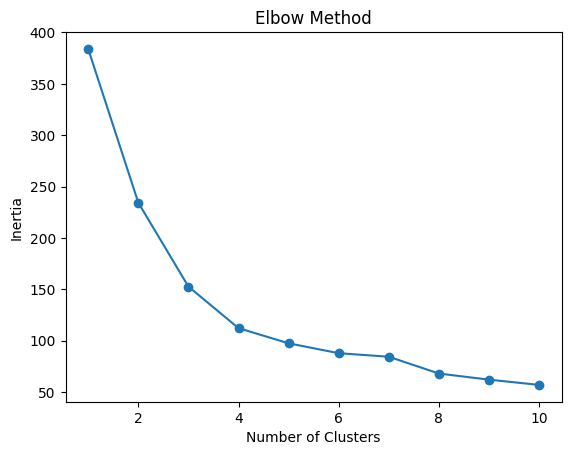

In [40]:
import matplotlib.pyplot as plt

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [41]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

cluster_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

In [42]:
cluster_df.groupby("Cluster")[[
    "Runs",
    "StrikeRate",
    "BoundaryPct"
]].mean().round(2)

,Runs,StrikeRate,BoundaryPct
Cluster,,,
0,2064.05,139.76,63.88
1,1478.90,122.71,54.99
2,1937.12,160.06,72.55
3,5270.50,133.59,58.16


In [43]:
cluster_df["Cluster"].value_counts()

Cluster
1    50
0    44
3    18
2    16
Name: count, dtype: int64

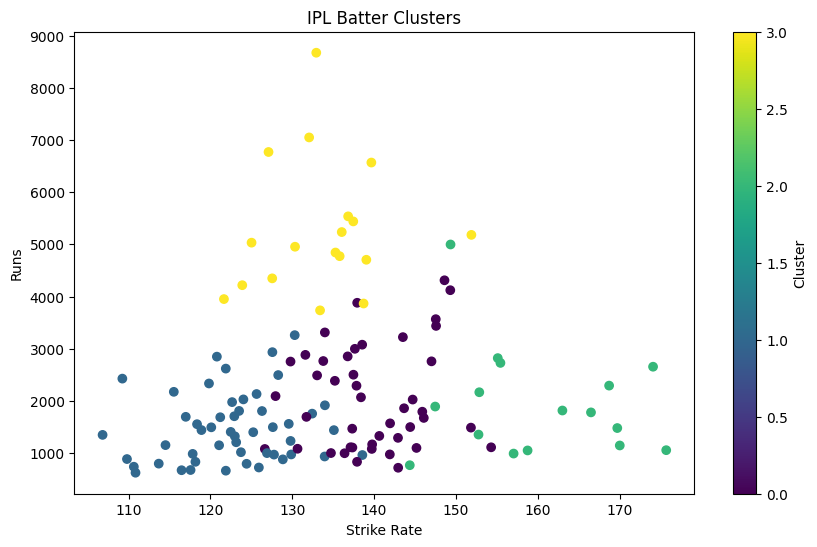

In [45]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    cluster_df["StrikeRate"],
    cluster_df["Runs"],
    c=cluster_df["Cluster"]
)

plt.xlabel("Strike Rate")
plt.ylabel("Runs")
plt.title("IPL Batter Clusters")

plt.colorbar(scatter,label="Cluster")

plt.show()

In [46]:
for c in sorted(cluster_df["Cluster"].unique()):
    
    print(f"\nCluster {c}")
    
    display(
        cluster_df[
            cluster_df["Cluster"] == c
        ][[
            "batter",
            "Runs",
            "StrikeRate",
            "BoundaryPct"
        ]].sort_values(
            "Runs",
            ascending=False
        ).head(10)
    )


Cluster 0


,batter,Runs,StrikeRate,BoundaryPct
553,SA Yadav,4311,148.603930,65.506843
248,JC Buttler,4121,149.311594,66.537248
588,SR Watson,3880,137.931034,68.247423
513,RR Pant,3566,147.538271,64.610208
285,KA Pollard,3437,147.574066,64.823974
470,Q de Kock,3312,133.980583,63.526570
693,YK Pathan,3222,143.518931,62.631906
150,DA Miller,3077,138.541198,55.508612
236,Ishan Kishan,2998,137.649219,65.243496
104,BB McCullum,2882,131.598174,67.730743



Cluster 1


,batter,Runs,StrikeRate,BoundaryPct
492,RA Jadeja,3260,130.295763,50.981595
682,WP Saha,2934,127.565217,58.145876
444,PA Patel,2848,120.780322,61.587079
352,M Vijay,2619,121.870638,58.571974
586,SPD Smith,2495,128.277635,50.661323
257,JH Kallis,2427,109.225923,52.904821
587,SR Tendulkar,2334,119.815195,58.183376
475,R Dravid,2174,115.515409,57.221711
309,KS Williamson,2132,125.633471,53.095685
268,JP Duminy,2029,124.022005,48.201084



Cluster 2


,batter,Runs,StrikeRate,BoundaryPct
128,CH Gayle,4997,149.342499,75.765459
208,GJ Maxwell,2820,155.115512,68.014184
661,V Sehwag,2728,155.441595,72.287390
40,AD Russell,2655,174.098361,78.568738
412,N Pooran,2293,168.727005,71.260358
692,YBK Jaiswal,2166,152.858151,73.314866
458,PP Shaw,1892,147.466875,69.661734
71,Abhishek Sharma,1816,163.016158,71.696035
585,SP Narine,1780,166.510758,81.573034
213,H Klaasen,1480,169.724771,62.567568



Cluster 3


,batter,Runs,StrikeRate,BoundaryPct
658,V Kohli,8671,132.929634,55.910506
500,RG Sharma,7048,132.059209,62.116913
535,S Dhawan,6769,127.093504,58.945191
151,DA Warner,6567,139.663973,61.946094
569,SK Raina,5536,136.826495,58.670520
389,MS Dhoni,5439,137.452616,56.701600
297,KL Rahul,5235,136.044699,58.452722
31,AB de Villiers,5181,151.890941,61.262305
51,AM Rahane,5032,125.018634,55.604134
524,RV Uthappa,4954,130.334123,60.880097


In [47]:
cluster_df.to_csv(
    "ipl_batter_clusters.csv",
    index=False
)

In [48]:
cluster_df.groupby("Cluster")["batter"].count()

Cluster
0    44
1    50
2    16
3    18
Name: batter, dtype: int64